### Simulación **sin tratamiento quimioterapéutico** ($\beta$ = 0)

Para analizar el crecimiento natural del tumor se considera inicialmente el caso sin tratamiento quimioterapéutico. En este escenario se supone que no existe administración externa de fármaco, es decir,

$$
u(t)=0,
\qquad
\beta_0(x)=0.
$$

Bajo estas hipótesis, la ecuación que describe la concentración del fármaco

$$
\frac{\partial \beta}{\partial t}
-
\mu\Delta\beta
=
-\delta\beta
+
u(t)
$$

admite como solución trivial

$$
\beta(x,t)\equiv 0
\qquad
\text{en } \Omega\times(0,T).
$$

En consecuencia, el término de interacción tumor--fármaco se anula:

$$
-\gamma c\beta = 0,
$$

y el sistema se reduce a la ecuación de reacción-difusión con crecimiento Gompertziano:

$$
\partial_t c
-
\nabla \cdot \left(D(x)\nabla c\right)
=
a\, c \ln\left(\frac{K}{c}\right).
$$

En lo que sigue se implementa una aproximación numérica mediante un esquema explícito de diferencias finitas para estudiar la evolución espacial del tumor y el crecimiento de la masa tumoral total en ausencia de tratamiento.

Carpeta creada en: C:\Users\fatim\Desktop\TFM_Simulacion_Sin_Tratamiento
Numero de pasos temporales: 150000
Condicion CFL satisfecha: True


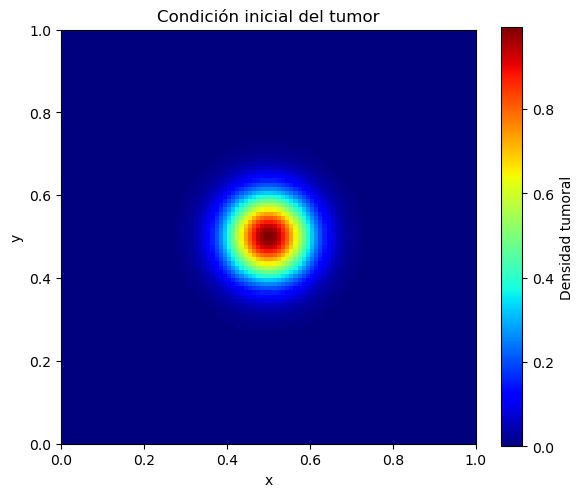

100%|██████████| 150000/150000 [01:08<00:00, 2198.63it/s]
C:\Users\fatim\AppData\Local\Temp\ipykernel_13048\2250188557.py:195: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


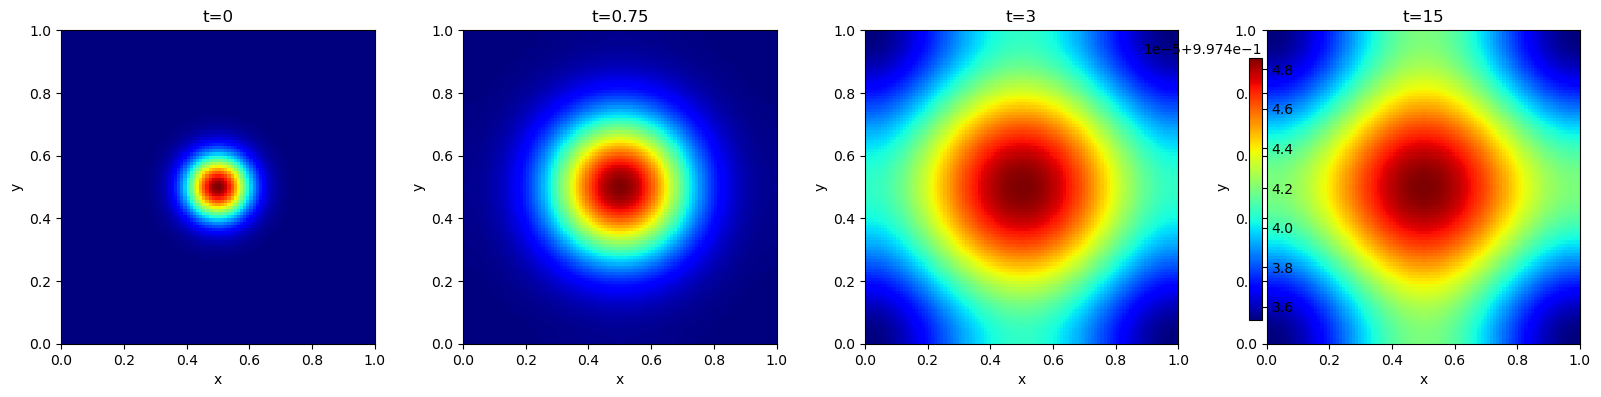

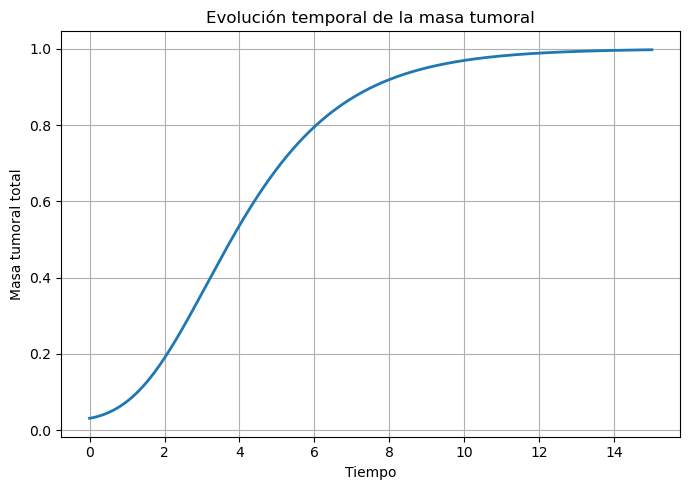


Simulación finalizada correctamente.

Archivos generados:
- condicion_inicial_tumor.png
- evolucion_sin_tratamiento.png
- masa_tumoral.png
- evolucion_tumoral.gif

Ubicación: C:\Users\fatim\Desktop\TFM_Simulacion_Sin_Tratamiento


In [1]:
# =====================================================
# LIBRERÍAS
# =====================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import os
from tqdm import tqdm

# =====================================================
# CREAR CARPETA EN EL ESCRITORIO
# =====================================================

ruta_escritorio = os.path.join(os.path.expanduser("~"), "Desktop")
ruta_figuras = os.path.join(ruta_escritorio, "TFM_Simulacion_Sin_Tratamiento")

os.makedirs(ruta_figuras, exist_ok=True)

print(f"Carpeta creada en: {ruta_figuras}")

# =====================================================
# PARÁMETROS DEL MODELO
# =====================================================

D = 0.01       # difusion tumoral
a = 0.5        # proliferacion
K = 1.0        # capacidad de carga

# =====================================================
# DOMINIO ESPACIAL
# =====================================================

Lx, Ly = 1.0, 1.0
Nx, Ny = 100, 100

dx = Lx / Nx
dy = Ly / Ny

x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)

X, Y = np.meshgrid(x, y, indexing='ij')

# =====================================================
# DISCRETIZACIÓN TEMPORAL
# =====================================================

T = 15.0
dt = 1e-4
Nt = int(T / dt)

print(f"Numero de pasos temporales: {Nt}")

# =====================================================
# CONDICIÓN CFL
# =====================================================

cfl = dt <= dx**2 / (4 * D)

print(f"Condicion CFL satisfecha: {cfl}")

# =====================================================
# CONDICIÓN INICIAL
# =====================================================

x0, y0 = 0.5, 0.5
sigma = 0.10
c0 = 1.0

c = c0 * np.exp(
    -((X - x0)**2 + (Y - y0)**2) / sigma**2
)

# =====================================================
# FIGURA 1: CONDICIÓN INICIAL
# =====================================================

plt.figure(figsize=(6,5))

im = plt.imshow(
    c,
    extent=[0,1,0,1],
    origin='lower',
    cmap='jet'
)

plt.colorbar(im, label='Densidad tumoral')

plt.xlabel('x')
plt.ylabel('y')

plt.title('Condición inicial del tumor')

plt.tight_layout()

plt.savefig(
    os.path.join(ruta_figuras, 'condicion_inicial_tumor.png'),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# =====================================================
# LISTAS PARA GUARDAR RESULTADOS
# =====================================================

masa = []
frames = []

# =====================================================
# FUNCIÓN LAPLACIANA
# =====================================================

def laplaciano(Z):

    Ztop = np.roll(Z, -1, axis=0)
    Zbottom = np.roll(Z, 1, axis=0)
    Zleft = np.roll(Z, -1, axis=1)
    Zright = np.roll(Z, 1, axis=1)

    lap = (
        (Ztop - 2 * Z + Zbottom) / dx**2 +
        (Zleft - 2 * Z + Zright) / dy**2
    )

    return lap

# =====================================================
# SIMULACIÓN TEMPORAL
# =====================================================

for n in tqdm(range(Nt)):

    c_old = c.copy()

    # Operador laplaciano
    lap = laplaciano(c_old)

    # Termino de reaccion Gompertz
    reaction = a * c_old * np.log(K / (c_old + 1e-12))

    # Actualizacion explicita
    c = c_old + dt * (D * lap + reaction)

    # Positividad
    c = np.maximum(c, 0)

    # Condiciones de Neumann
    c[0,:] = c[1,:]
    c[-1,:] = c[-2,:]
    c[:,0] = c[:,1]
    c[:,-1] = c[:,-2]

    # Masa tumoral
    masa_total = np.sum(c) * dx * dy
    masa.append(masa_total)

    # Guardar frames
    if n % 200 == 0:
        frames.append(c.copy())

# =====================================================
# FIGURA 2: EVOLUCIÓN TEMPORAL
# =====================================================

fig, axes = plt.subplots(1,4, figsize=(16,4))

indices = [
    0,               
    int(0.05*len(frames)),   
    int(0.2*len(frames)),   
    -1            
]

titulos = [
    't=0',
    't=0.75',
    't=3',
    't=15'
]

for ax, idx, titulo in zip(axes, indices, titulos):

    im = ax.imshow(
        frames[idx],
        extent=[0,1,0,1],
        origin='lower',
        cmap='jet'
    )

    ax.set_title(titulo)
    ax.set_xlabel('x')
    ax.set_ylabel('y')

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.85)

plt.tight_layout()

plt.savefig(
    os.path.join(ruta_figuras, 'evolucion_sin_tratamiento.png'),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# =====================================================
# FIGURA 3: MASA TUMORAL
# =====================================================

plt.figure(figsize=(7,5))

plt.plot(np.linspace(0, T, Nt), masa, linewidth=2)

plt.xlabel('Tiempo')
plt.ylabel('Masa tumoral total')

plt.title('Evolución temporal de la masa tumoral')

plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(ruta_figuras, 'masa_tumoral.png'),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# =====================================================
# GIF ANIMADO
# =====================================================

fig, ax = plt.subplots(figsize=(6,5))

im = ax.imshow(
    frames[0],
    extent=[0,1,0,1],
    origin='lower',
    cmap='jet',
    animated=True
)

ax.set_title('Evolución tumoral')
ax.set_xlabel('x')
ax.set_ylabel('y')

plt.colorbar(im, ax=ax)

def update(frame):
    im.set_array(frame)
    return [im]

ani = FuncAnimation(
    fig,
    update,
    frames=frames,
    interval=100,
    blit=True
)

ani.save(
    os.path.join(ruta_figuras, 'evolucion_tumoral.gif'),
    writer=PillowWriter(fps=10)
)

plt.close()

# =====================================================
# MENSAJE FINAL
# =====================================================

print("\nSimulación finalizada correctamente.")
print("\nArchivos generados:")
print("- condicion_inicial_tumor.png")
print("- evolucion_sin_tratamiento.png")
print("- masa_tumoral.png")
print("- evolucion_tumoral.gif")
print(f"\nUbicación: {ruta_figuras}")